$dy = k~ydt$

$y(0) = y_0,~ t\in [0,T]$

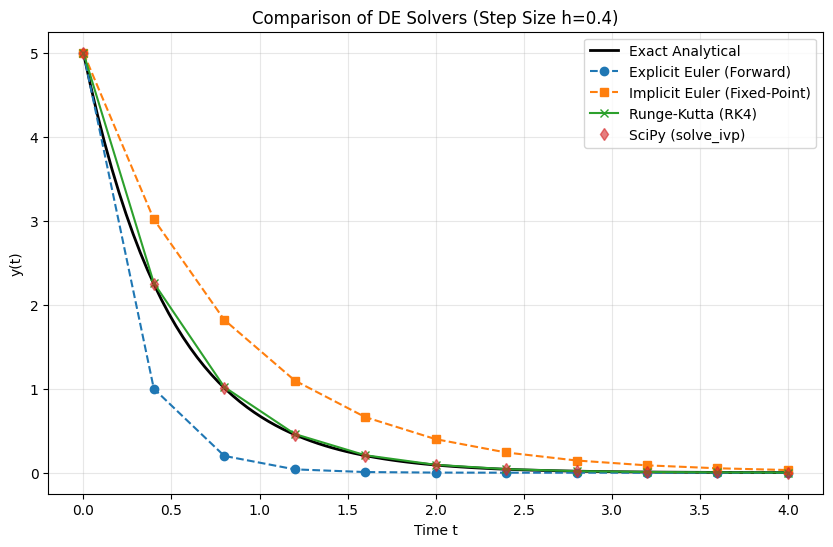

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
k = 2.0         # Decay constant
y0 = [5.0]      # Initial condition
t_span = (0, 4) # Time interval
h = 0.4         # Step size (kept large to show differences in accuracy)
t_steps = np.arange(t_span[0], t_span[1] + h, h)

# 1. ANALYTICAL SOLUTION
def exact_sol(t):
    return y0[0] * np.exp(-k * t)

# 2. EXPLICIT EULER (The simplest method)
y_euler = [y0[0]]
for i in range(len(t_steps)-1):
    y_next = y_euler[-1] + h * (-k * y_euler[-1])
    y_euler.append(y_next)

# 3. FIXED-POINT ITERATION (Inside an Implicit Backward Euler step)
# Formula: y_next = y_prev + h * (-k * y_next)
# Iteration: y_next_guess = y_prev + h * (-k * y_next_guess)
y_implicit = [y0[0]]
for i in range(len(t_steps)-1):
    y_prev = y_implicit[-1]
    y_guess = y_prev  # Initial guess
    # Iterate to find the fixed point
    for _ in range(10): 
        y_guess = y_prev + h * (-k * y_guess)
    y_implicit.append(y_guess)

# 4. RUNGE-KUTTA (RK4 - Higher order accuracy)
y_rk4 = [y0[0]]
def f(t, y): return -k * y

for i in range(len(t_steps)-1):
    tn = t_steps[i]
    yn = y_rk4[-1]
    k1 = f(tn, yn)
    k2 = f(tn + h/2, yn + h/2 * k1)
    k3 = f(tn + h/2, yn + h/2 * k2)
    k4 = f(tn + h, yn + h * k3)
    y_next = yn + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    y_rk4.append(y_next)

# 5. SCIPY SOLVER (Modern Adaptive Step Library)
sol = solve_ivp(f, t_span, y0, t_eval=t_steps)

# --- Plotting ---
plt.figure(figsize=(10, 6))
t_fine = np.linspace(t_span[0], t_span[1], 100)

plt.plot(t_fine, exact_sol(t_fine), 'k', label='Exact Analytical', linewidth=2)
plt.plot(t_steps, y_euler, 'o--', label='Explicit Euler (Forward)')
plt.plot(t_steps, y_implicit, 's--', label='Implicit Euler (Fixed-Point)')
plt.plot(t_steps, y_rk4, 'x-', label='Runge-Kutta (RK4)')
plt.plot(sol.t, sol.y[0], 'd', label='SciPy (solve_ivp)', alpha=0.6)

plt.title(f'Comparison of DE Solvers (Step Size h={h})')
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


$dy = \alpha~ydt + \sigma~ ydw$

$y(0) = y_0,~ t\in [0,T], dw\sim \mathcal{N}(0)$

Stability ratio r: 0.3050


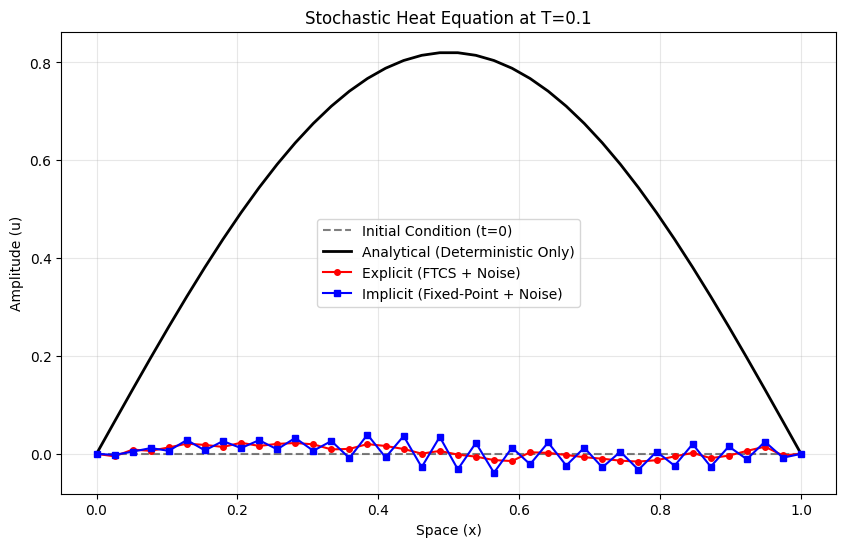

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
L = 1.0          # Length of domain
T = 0.1          # Total time
nx = 40          # Number of spatial points
nt = 100         # Number of time steps
alpha = 0.2005      # Diffusion coefficient
sigma = 0.2      # Noise intensity

dx = L / (nx - 1)
dt = T / nt
x = np.linspace(0, L, nx)

# Stability check for explicit: r must be < 0.5
r = alpha * dt / (dx**2)
print(f"Stability ratio r: {r:.4f}")

# Initial Condition: A smooth sine wave
u0 = np.sin(np.pi * x)*0


# Generate Stochastic Noise (Wiener Process increments)
# Scale by sqrt(dt) for the Brownian motion property
dW = np.random.normal(0, np.sqrt(dt), (nt, nx))

# 1. EXPLICIT SOLVER (Euler-Maruyama / FTCS)
u_explicit = u0.copy()
for tn in range(nt):
    u_new = np.copy(u_explicit)
    for i in range(1, nx-1):
        diffusion = r * (u_explicit[i+1] - 2*u_explicit[i] + u_explicit[i-1])
        noise = sigma * dW[tn, i]
        u_new[i] = u_explicit[i] + diffusion + noise
    u_explicit = u_new

# 2. IMPLICIT SOLVER (BTCS via Fixed-Point Iteration)
# Equation: u_next = u_prev + r*(diff_next) + noise
u_implicit = u0.copy()
for tn in range(nt):
    u_prev = np.copy(u_implicit)
    u_guess = np.copy(u_implicit) 
    noise = sigma * dW[tn, :]
    
    # Fixed-Point Iteration Loop (Inner Loop)
    for _ in range(5): 
        u_next_iter = np.copy(u_guess)
        for i in range(1, nx-1):
            # Implicit update step
            u_next_iter[i] = u_prev[i] + r * (u_guess[i+1] - 2*u_guess[i] + u_guess[i-1]) + noise[i]
        u_guess = u_next_iter
    u_implicit = u_guess

# 3. ANALYTICAL (Approximate - Deterministic part only for reference)
u_analytical = np.sin(np.pi * x) * np.exp(-alpha * (np.pi**2) * T)

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(x, u0, 'k--', label='Initial Condition (t=0)', alpha=0.5)
plt.plot(x, u_analytical, 'k', label='Analytical (Deterministic Only)', linewidth=2)
plt.plot(x, u_explicit, 'r-o', label='Explicit (FTCS + Noise)', markersize=4)
plt.plot(x, u_implicit, 'b-s', label='Implicit (Fixed-Point + Noise)', markersize=4)

plt.title(f'Stochastic Heat Equation at T={T}')
plt.xlabel('Space (x)')
plt.ylabel('Amplitude (u)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

